In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
os.chdir('../')
import yaml
import torch
import numpy as np
import ecg_plot 
from matplotlib import pyplot as plt
from module.IBExtractor import IBExtractor
from module.vae_model import VAE_Decoder
from module.DiT_ECGTwin import ECGTwin_Edit
from diffusers import DDPMScheduler
from transformers import AutoModel, AutoTokenizer
from tqdm import tqdm
from utils.model_utils import build_noise_predictor
from utils.data_utils import process_pat_info, get_text_embedding, sex_transform

/home/laiyongfan/miniconda3/envs/Eren/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
ckpt_path = './checkpoints/ECGTwin_DiT.pth'
device_str = 'cuda:1'

config_path = "config/DiT_ECGTwin.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f) 

h_ = config['hyper_para']
model_type = config['meta']['model_type']
save_path = f'exp/batch_{model_type}'

meta = config['meta']
roots = config['dependencies']
h_ = config['hyper_para']
settings = config['inference_setting']

use_vae_latent = meta['vae_latent']     
n_channels = 4 if use_vae_latent else 12 

prerequisites = {}
prerequisites['tar'] = settings

reference_data = torch.load("data/prepared_input/normal_1.pt")
prerequisites['ref_latent'] = reference_data['data']
prerequisites['ref'] = reference_data['label']
batch = prerequisites['tar']['gen_batch']

In [3]:
device = torch.device(device_str if torch.cuda.is_available() else "cpu")
noise_predictor = build_noise_predictor(meta['model_type'], n_channels, h_)
noise_predictor_ckpt = torch.load(ckpt_path, map_location=device)
noise_predictor.load_state_dict(noise_predictor_ckpt)
noise_predictor.eval()
noise_predictor.to(device)

diffused_model = DDPMScheduler(num_train_timesteps=h_['ddpm']['num_train_steps'], beta_start=h_['ddpm']['beta_start'], beta_end=h_['ddpm']['beta_end'])
diffused_model.set_timesteps(settings['inference_timestep'])

ibe_model = IBExtractor(embed_dim=h_['ibe']['embed_dim'], num_heads=h_['ibe']['num_heads'], ff_hidden_size=h_['ibe']['ff_hidden_size'], num_layers=h_['ibe']['num_layers'], text_embed_dim=h_['ibe']['text_embed_dim'], patient_info_size=h_['ibe']['patient_info_size'])
ibe_model.load_state_dict(torch.load(roots['ibe_path'], map_location='cpu'))
ibe_model.eval()
ibe_model.to(device)

decoder = VAE_Decoder()
vae_path = config['dependencies']['vae_path']
vae_checkpoint = torch.load(vae_path, map_location=device)
decoder.load_state_dict(vae_checkpoint['decoder'])
decoder.to(device)
decoder.eval()

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
embedding_model = AutoModel.from_pretrained('nomic-ai/nomic-embed-text-v1.5', trust_remote_code=True, safe_serialization=True)
embedding_model.to(device)
embedding_model = embedding_model.eval()

<All keys matched successfully>


In [ ]:
ecg_editor = ECGTwin_Edit(in_channels=n_channels, hidden_size=h_['DiT']['hidden_size'], text_embed_dim=h_['ibe']['text_embed_dim'], 
                          pat_info_length=h_['DiT']['patient_info_size'], base_vector_dim=h_['ibe']['embed_dim'], depth=h_['DiT']['depth'],
                          num_heads=h_['DiT']['num_heads'])
ecg_editor.load_state_dict(noise_predictor_ckpt)
ecg_editor.eval()
ecg_editor = ecg_editor.to(device)

In [5]:
pat_info_ref = process_pat_info(normalize=True,
                                hr=torch.tensor([prerequisites['ref']['hr']]),
                                age=torch.tensor([prerequisites['ref']['age']]),
                                sex=torch.tensor([sex_transform(prerequisites['ref']['sex'])]))

pat_info_ref = pat_info_ref.repeat(batch, 1).to(device)

# (B, num_reports, 768)
text_embed_ref = prerequisites['ref']['text_embed'].unsqueeze(0).repeat(batch, 1, 1).to(device)

# (B, L, C)
latent_ref = prerequisites['ref_latent'].unsqueeze(0).repeat(batch, 1, 1).transpose(2, 1).to(device)

# (B, L, bv_dim)
base_vector = ibe_model.extract_features(latent_ref, text_embed_ref, None, pat_info_ref, reduce=True)

# prerequisites['tar']['text'] = "sinus rhythm|ventricular premature complex."
prerequisites['tar']['text'] = "sinus rhythm|Low QRS voltages in precordial leads|abnormal ecg"
# prerequisites['tar']['text'] = "sinus rhythm|borderline ecg"
prerequisites['tar']['hr'] = 80

text_embed_tar = get_text_embedding(text=prerequisites['tar']['text'],
                                    tokenizer=tokenizer,
                                    embedding_model=embedding_model,
                                    mix=config['meta']['mix'])
text_embed_tar = text_embed_tar.unsqueeze(0).repeat(batch, 1, 1)

pat_info_tar = process_pat_info(normalize=True,
                                add_token=False,
                                hr=torch.tensor([prerequisites['tar']['hr']]),
                                age=torch.tensor([prerequisites['tar']['age']]),
                                sex=torch.tensor([sex_transform(prerequisites['ref']['sex'])]))
pat_info_tar = pat_info_tar.repeat(batch, 1).to(device)

In [ ]:
# text_edit = "sinus rhythm|normal ecg."
text_edit = "sinus rhythm|ventricular premature complex."
text_embed_edit= get_text_embedding(text=text_edit,
                                    tokenizer=tokenizer,
                                    embedding_model=embedding_model,
                                    mix=config['meta']['mix'])
text_embed_edit = text_embed_edit.unsqueeze(0).repeat(batch, 1, 1)

In [6]:
text_add = "Right bundle branch block"
# text_add = "*** consider acute st elevation mi ***"
# text_add = "ventricular premature complex."
text_embed_edit= get_text_embedding(text=text_add,
                                    tokenizer=tokenizer,
                                    embedding_model=embedding_model,
                                    mix=config['meta']['mix'])
text_embed_edit = text_embed_edit.unsqueeze(0).repeat(batch, 1, 1)

In [7]:
from copy import copy

BASE_SEED = 1
T_THRESHOLD = 200
g_src = torch.Generator()
g_src.manual_seed(BASE_SEED)
g_edit = torch.Generator()
g_edit.manual_seed(BASE_SEED)
with torch.no_grad():
    x_src = torch.randn(batch, 4, 128)
    x_edit = copy(x_src)
    x_src = x_src.to(device)
    x_edit = x_edit.to(device)

    timesteps = tqdm(diffused_model.timesteps)
    for _, i in enumerate(timesteps):
        t = i*torch.ones(batch, dtype=torch.long, device=device)

        if i.item() < T_THRESHOLD:
            # noise_src, noise_edit = ecg_editor.swap_report(x_src, x_edit, t, text_embed_tar, text_embed_edit, pat_info_tar, base_vector)
            noise_src, noise_edit = ecg_editor.add_report(x_src, x_edit, t, text_embed_tar, text_embed_edit, pat_info_tar, base_vector, weight=1.0)
        else:
            noise_src = ecg_editor(x_src, t, text_embed_tar, None, pat_info_tar, base_vector)
            noise_edit = noise_src

        x_src = diffused_model.step(model_output=noise_src, 
                                timestep=i, 
                                sample=x_src,
                                generator=g_src)['prev_sample']

        x_edit = diffused_model.step(model_output=noise_edit, 
                                timestep=i, 
                                sample=x_edit,
                                generator=g_edit)['prev_sample']

batch_gen_ecg_src = decoder(x_src).cpu().detach().numpy()
batch_gen_ecg_edit = decoder(x_edit).cpu().detach().numpy()

100%|██████████| 1000/1000 [00:09<00:00, 102.00it/s]


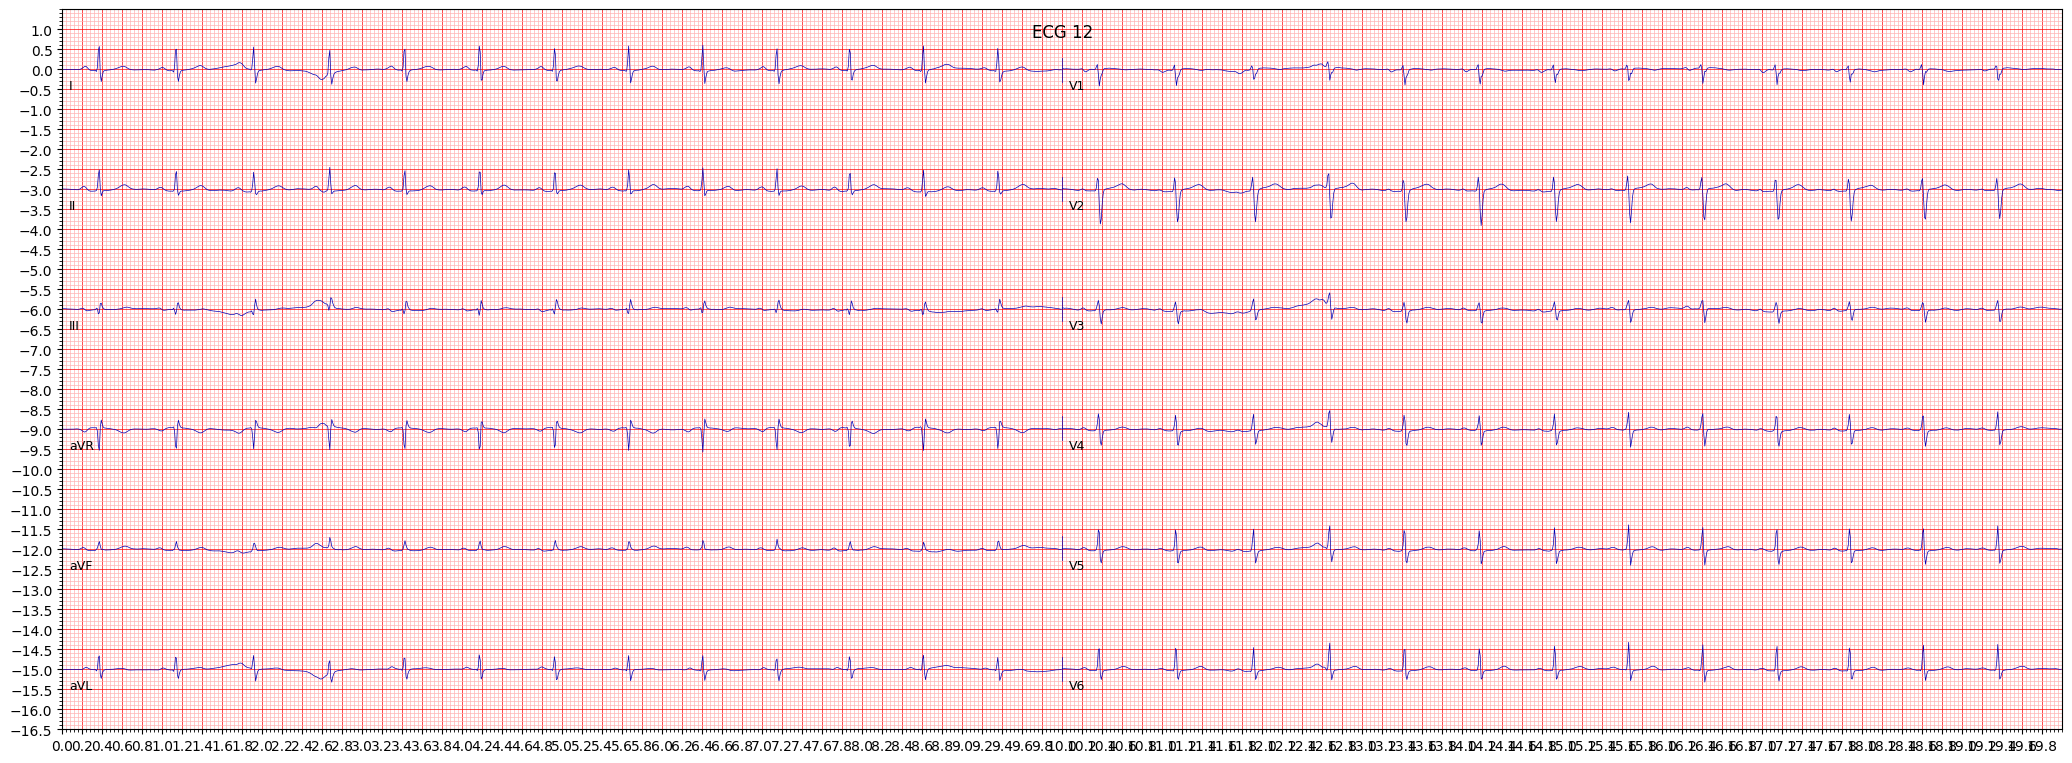

In [8]:
sample_ids = 5
lead_name = ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
generated_ecg_src = batch_gen_ecg_src[sample_ids]
# (C, L)
ecg_plot.plot(generated_ecg_src.transpose(1, 0), 102.4, lead_index=lead_name) 
plt.show()

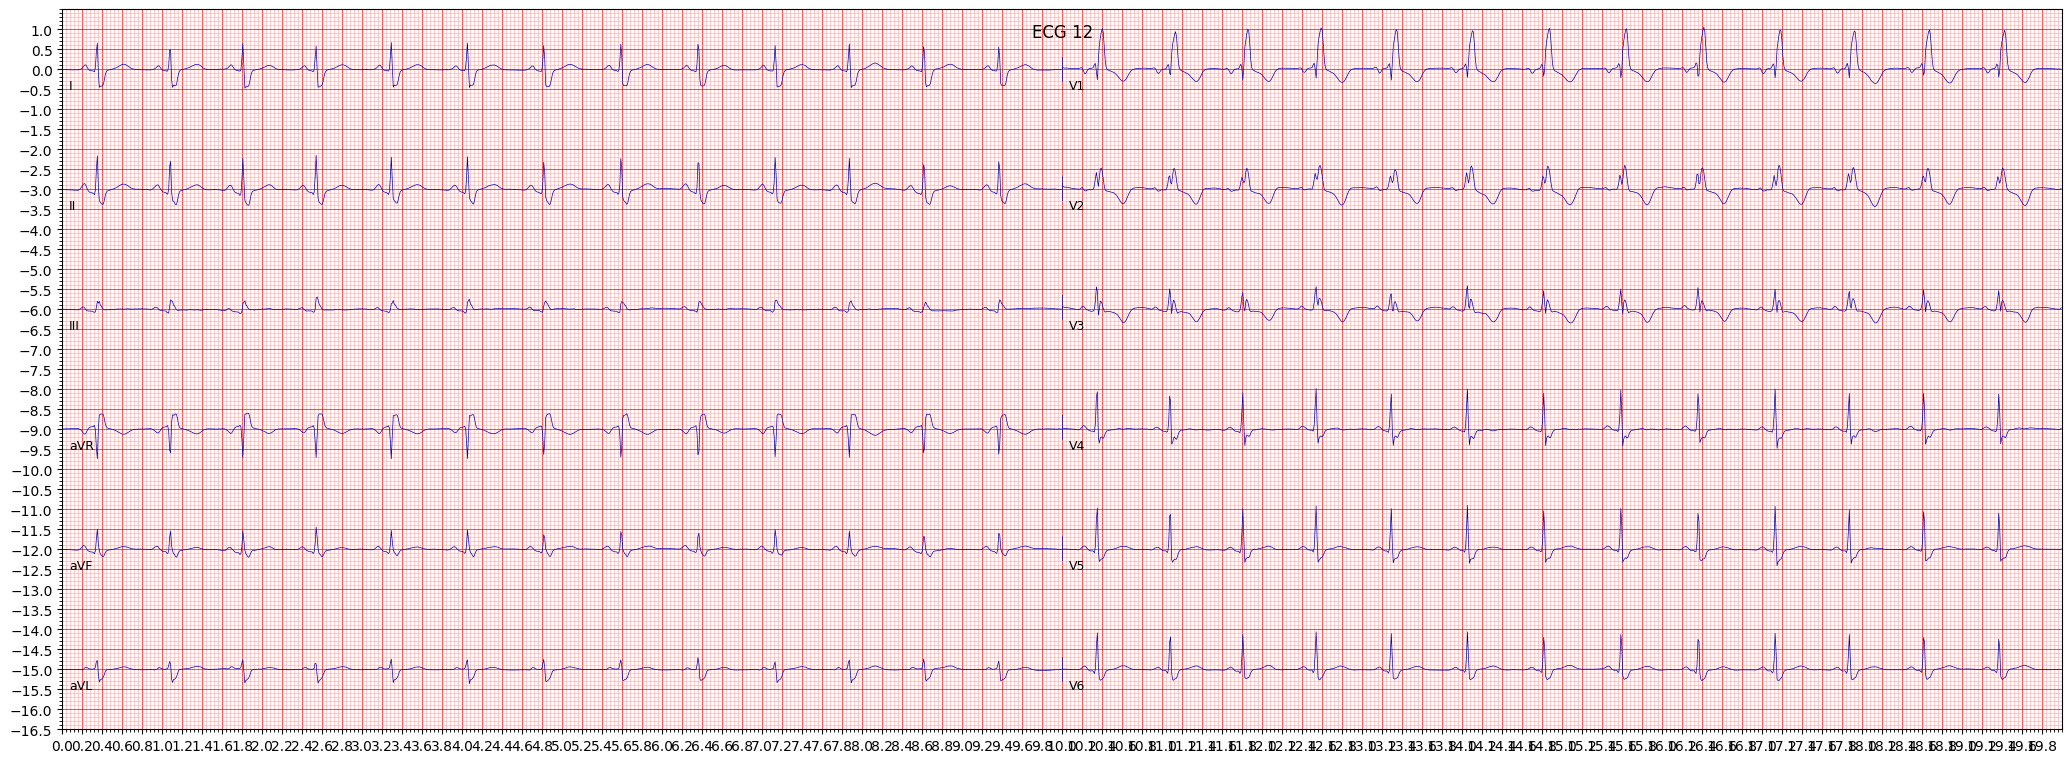

In [9]:
sample_ids = 5
generated_ecg_edit = batch_gen_ecg_edit[sample_ids]
# (C, L)
ecg_plot.plot(generated_ecg_edit.transpose(1, 0), 102.4, lead_index=lead_name) 
plt.show()

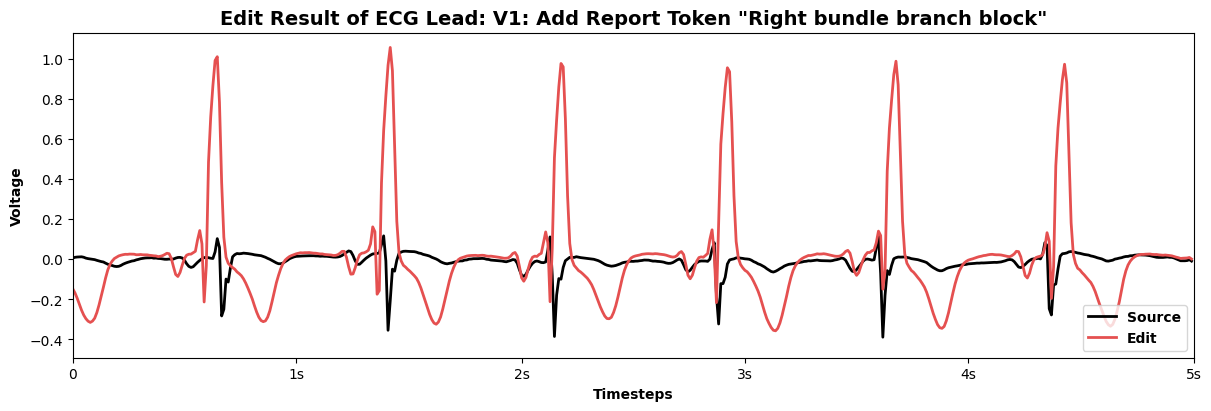

In [ ]:
sample_ids = 5
lead_ids = 6
generated_ecg_src = batch_gen_ecg_src[sample_ids]
generated_ecg_edit = batch_gen_ecg_edit[sample_ids]
lead_name = ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
# Original signal
ax.plot(generated_ecg_src[:,lead_ids], label=f'Source', color='black', linewidth=2)
# ax.plot(generated_ecg_edit_0[:,lead_ids], label=f'Add New Token', color='#129990', linewidth=2)
ax.plot(generated_ecg_edit[:,lead_ids], label=f'Edit', color='#E55050', linewidth=2)

plt.legend(loc="lower right", prop={"weight": "bold"})
# plt.title(f'Edit Result of ECG Lead: {lead_name[lead_ids]}: Add Report Token "ventricular premature complex."', fontsize=14, weight='bold')
plt.title(f'Edit Result of ECG Lead: {lead_name[lead_ids]}: Add Report Token "{text_add}"', fontsize=14, weight='bold')
plt.xlabel('Timesteps', fontsize=10, weight='bold')

# plt.xlim(0, 512)
# plt.xticks(ticks=[0, 102, 205, 306, 409, 512], labels=['0', '1s', '2s', '3s', '4s', '5s'])

plt.xlim(512, 1024)
plt.xticks(ticks=[512, 614, 717, 819, 921, 1024], labels=['0', '1s', '2s', '3s', '4s', '5s'])

# plt.xlim(0, 1024)
# plt.xticks(ticks=[0, 102, 205, 307, 409, 512, 614, 717, 819, 921, 1024], 
#            labels=['0', '1s', '2s', '3s', '4s', '5s', '6s', '7s', '8s', '9s', '10s'])

plt.ylabel('Voltage', fontsize=10, weight='bold')
plt.savefig(f'figure/ecg_edit/rbbb_{lead_name[lead_ids]}.pdf', dpi=300)
plt.show()

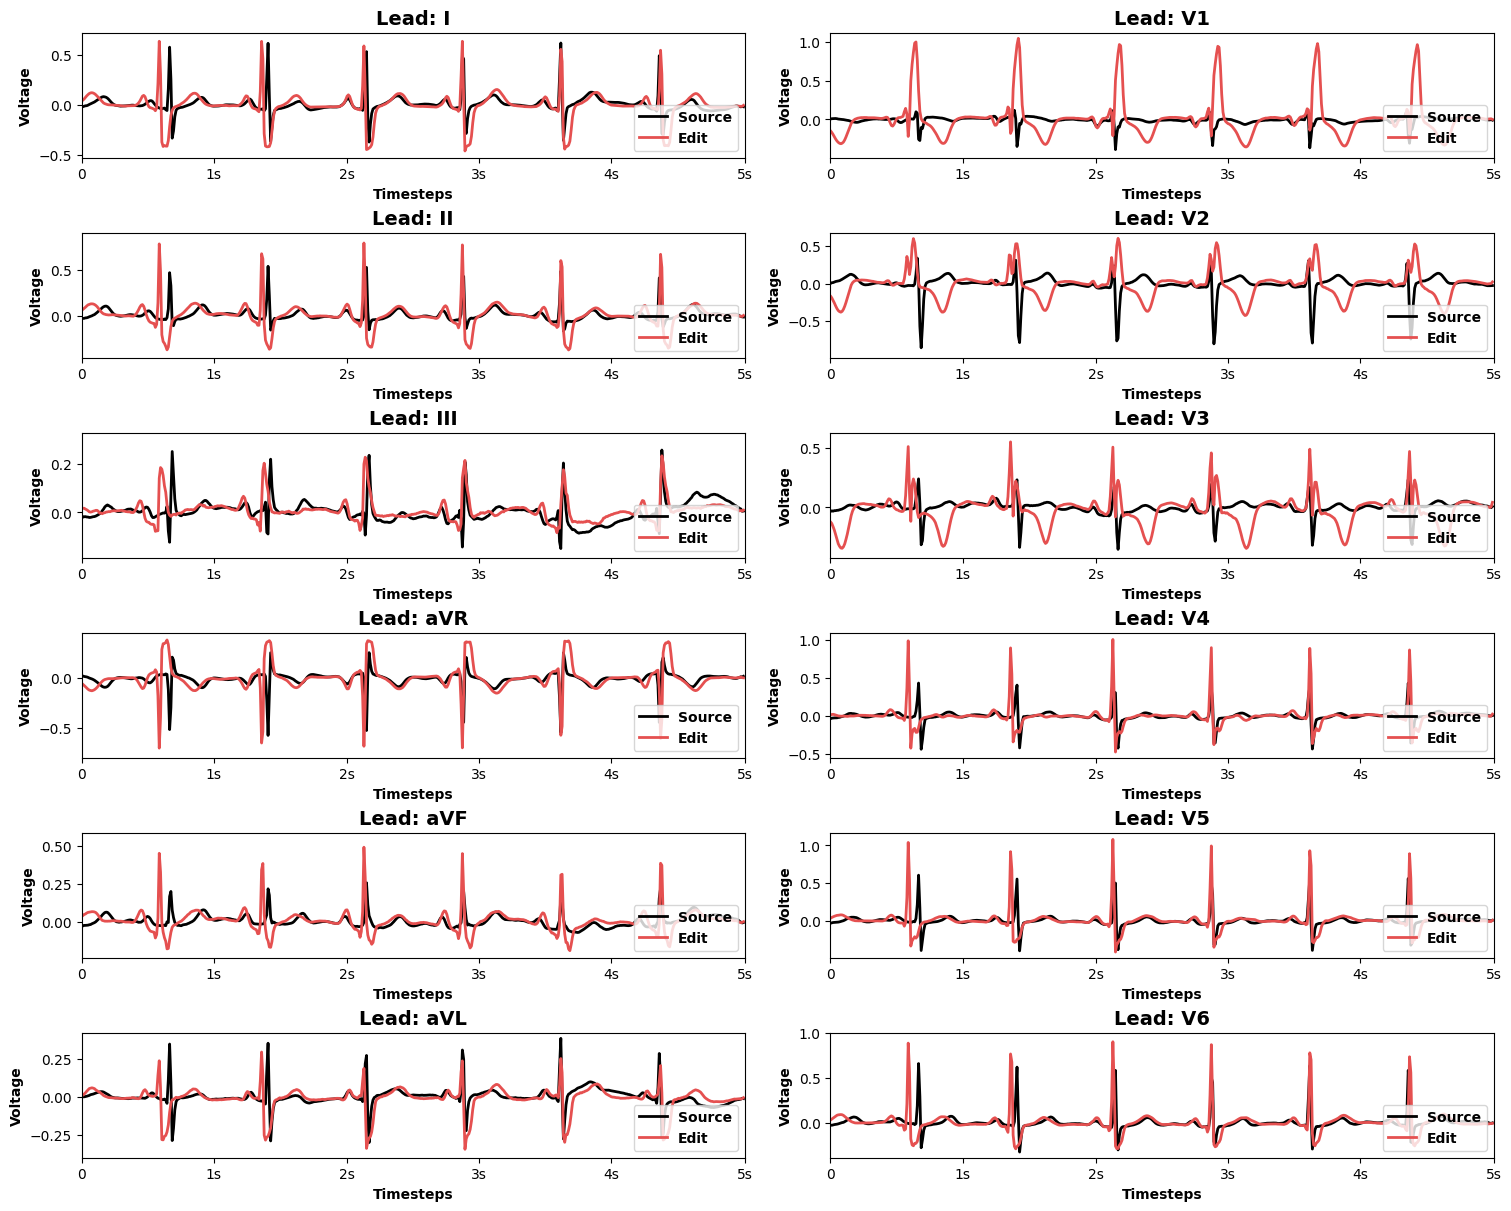

In [ ]:
sample_ids = 5
generated_ecg_src = batch_gen_ecg_src[sample_ids]
generated_ecg_edit = batch_gen_ecg_edit[sample_ids]
lead_name = ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
fig, axes = plt.subplots(6, 2, figsize=(15, 12), constrained_layout=True)
axes = axes.T.flatten()

for idx in range(12):
    axes[idx].plot(generated_ecg_src[:,idx], label=f'Source', color='black', linewidth=2)
    axes[idx].plot(generated_ecg_edit[:,idx], label=f'Edit', color='#E55050', linewidth=2)
    axes[idx].set_title(f'Lead: {lead_name[idx]}', fontsize=14, weight='bold')

    axes[idx].legend(loc="lower right", prop={"weight": "bold"})
    axes[idx].set_xlabel('Timesteps', fontsize=10, weight='bold')

    # axes[idx].set(xlim=(0, 512))
    # axes[idx].set_xticks([0, 102, 205, 306, 409, 512])
    # axes[idx].set_xticklabels(['0', '1s', '2s', '3s', '4s', '5s'])

    axes[idx].set(xlim=(512, 1024))
    axes[idx].set_xticks([512, 614, 717, 819, 921, 1024])
    axes[idx].set_xticklabels(['0', '1s', '2s', '3s', '4s', '5s'])

    # axes[idx].set(xlim=(0, 1024))
    # axes[idx].set_xticks([0, 102, 205, 307, 409, 512, 614, 717, 819, 921, 1024]) 
    # axes[idx].set_xticklabels(['0', '1s', '2s', '3s', '4s', '5s', '6s', '7s', '8s', '9s', '10s'])
    axes[idx].set_ylabel('Voltage', fontsize=10, weight='bold')
# plt.savefig('figure/ecg_edit/rbbb.pdf', dpi=300)
plt.show()